In [16]:
# Import Libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [6]:
#  Load dataset
df = pd.read_csv('../data/raw/exoplanet_data.csv', comment= '#')

In [7]:

df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,AU Mic b,AU Mic,1,1,4,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2024-09-28,2023-12,2024-09-28
1,AU Mic c,AU Mic,1,1,4,Transit,2021.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2024-09-28,2023-12,2024-09-28
2,BD+05 4868 A b,BD+05 4868 A,1,2,1,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.010,7.448,0.026,-0.026,9.84152,0.000476,-0.000476,2025-03-21,2025-01,2025-03-21
3,BD-14 3065 b,BD-14 3065 A,1,3,1,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.013,9.932,0.026,-0.026,10.91000,0.001617,-0.001617,2024-06-25,2024-03,2024-06-25
4,DS Tuc A b,DS Tuc A,1,2,1,Transit,2019.0,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,6.676,0.034,-0.034,8.31926,0.001025,-0.001025,2019-07-03,2019-07,2019-07-11


In [8]:
df.shape

(746, 92)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 92 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          746 non-null    object 
 1   hostname         746 non-null    object 
 2   default_flag     746 non-null    int64  
 3   sy_snum          746 non-null    int64  
 4   sy_pnum          746 non-null    int64  
 5   discoverymethod  746 non-null    object 
 6   disc_year        745 non-null    float64
 7   disc_facility    746 non-null    object 
 8   soltype          746 non-null    object 
 9   pl_controv_flag  746 non-null    int64  
 10  pl_refname       746 non-null    object 
 11  pl_orbper        743 non-null    float64
 12  pl_orbpererr1    723 non-null    float64
 13  pl_orbpererr2    723 non-null    float64
 14  pl_orbperlim     743 non-null    float64
 15  pl_orbsmax       652 non-null    float64
 16  pl_orbsmaxerr1   639 non-null    float64
 17  pl_orbsmaxerr2  

In [7]:
df.describe()

,default_flag,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
count,746.0,746.000000,746.000000,745.000000,746.000000,743.000000,7.230000e+02,7.230000e+02,743.0,652.000000,...,741.000000,741.000000,741.000000,741.000000,744.000000,742.000000,742.000000,744.000000,744.000000,744.000000
mean,1.0,1.121984,1.631367,2022.777181,0.004021,13.874506,1.965765e-03,-1.787445e-03,0.0,0.090386,...,-1.611606,11.524677,0.053822,-0.053822,9.039074,0.035345,-0.035345,11.131019,0.000500,-0.000500
std,0.0,0.355020,1.069169,1.783667,0.063330,30.385708,2.664913e-02,2.449135e-02,0.0,0.105419,...,3.255803,2.087233,0.102442,0.102442,1.502603,0.366202,0.366202,1.847145,0.000422,0.000422
min,1.0,1.000000,1.000000,2018.000000,0.000000,0.238182,2.800000e-08,-5.800000e-01,0.0,0.006220,...,-32.536000,5.650000,0.002000,-1.133000,4.241000,0.011000,-9.995000,5.512800,0.000112,-0.004236
25%,1.0,1.000000,1.000000,2022.000000,0.000000,3.316956,4.000000e-06,-6.000000e-05,0.0,0.038325,...,-1.568000,9.969000,0.012000,-0.057000,8.054250,0.019000,-0.023000,9.776800,0.000263,-0.000586
50%,1.0,1.000000,1.000000,2023.000000,0.000000,5.799816,1.300000e-05,-1.335500e-05,0.0,0.060000,...,-0.360100,11.446000,0.030000,-0.030000,9.045500,0.021000,-0.021000,11.176100,0.000396,-0.000396
75%,1.0,1.000000,2.000000,2024.000000,0.000000,12.832443,6.000000e-05,-3.900000e-06,0.0,0.102175,...,-0.100400,12.603000,0.057000,-0.012000,10.171250,0.023000,-0.019000,12.218975,0.000586,-0.000263
max,1.0,3.000000,6.000000,2026.000000,1.000000,482.819100,5.900000e-01,-8.700000e-08,0.0,1.152000,...,-0.002835,18.000000,1.133000,-0.002000,15.548000,9.995000,-0.011000,16.958000,0.004236,-0.000112


In [9]:
# Missing value
df.isnull().sum()

# duplicates identify

df.drop_duplicates(inplace=True)
df.dropna(how='all', inplace=True)

print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


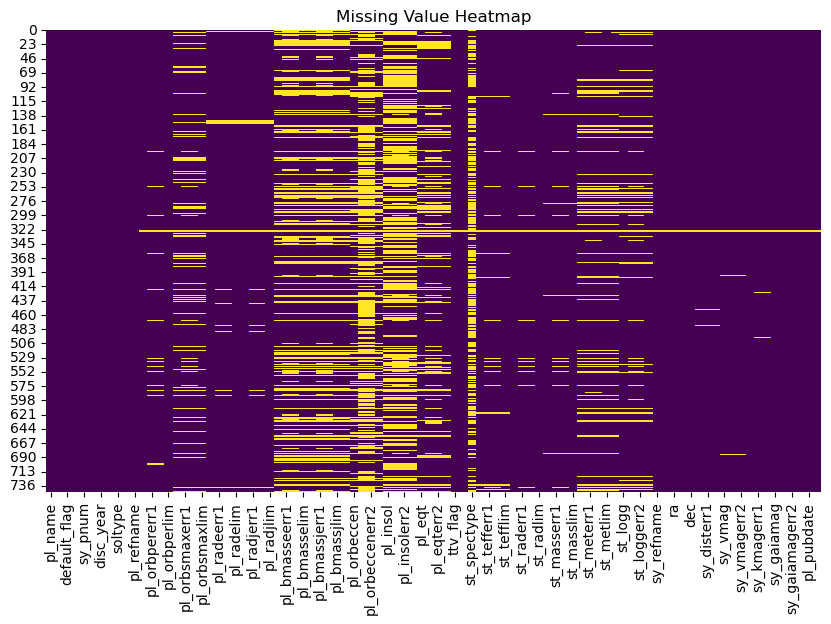

In [10]:
# Heatmap for Missing Values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

In [11]:
# Selecting features columns for habitability analysis

selected_cols = ['pl_name', 'pl_rade','pl_bmasse', 'pl_orbper','pl_orbsmax','pl_eqt','st_teff','st_rad','st_mass','st_met','st_spectype']

if 'pl_dens' in df.columns: selected_cols.append('pl_dens')
if 'st_lum' in df.columns: selected_cols.append('st_lum')

df_m1= df[selected_cols].copy()

df_m1.shape


(746, 11)

In [12]:
# Data Quality: Duplicates & Completely missing rows

df_m1.drop_duplicates(inplace=True)
df_m1.dropna(how='all', inplace=True)

In [13]:
# 3. Handling Missing Data 
num_cols = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'st_met',]
df_m1[num_cols] = df_m1[num_cols].apply(lambda x: x.fillna(x.median()))
df_m1['st_spectype'] = df_m1['st_spectype'].fillna(df_m1['st_spectype'].mode()[0])

In [14]:
df_m1['st_spectype'] = df_m1['st_spectype'].astype(str).str[0]

# One-Hot Encoding: Yeh 'st_spectype' ko numeric columns (0 aur 1) mein badal dega
df_m1 = pd.get_dummies(df_m1, columns=['st_spectype'], prefix='spec', drop_first=True)

In [15]:
df_m1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pl_name     746 non-null    object 
 1   pl_rade     746 non-null    float64
 2   pl_bmasse   746 non-null    float64
 3   pl_orbper   746 non-null    float64
 4   pl_orbsmax  746 non-null    float64
 5   pl_eqt      746 non-null    float64
 6   st_teff     746 non-null    float64
 7   st_rad      746 non-null    float64
 8   st_mass     746 non-null    float64
 9   st_met      746 non-null    float64
 10  spec_F      746 non-null    bool   
 11  spec_G      746 non-null    bool   
 12  spec_K      746 non-null    bool   
 13  spec_M      746 non-null    bool   
 14  spec_m      746 non-null    bool   
dtypes: bool(5), float64(9), object(1)
memory usage: 62.1+ KB


In [16]:
# 4. UNIT STANDARDIZATION (Ensuring Earth=1 and Sun=1)
if 'pl_bmassj' in df_m1.columns:
    df_m1['pl_bmasse'] = df_m1['pl_bmassj'] * 317.8
if 'pl_radj' in df_m1.columns:
    df_m1['pl_rade'] = df_m1['pl_radj'] * 11.21

In [17]:
# Remove physically impossible values

df_m1 = df_m1[
    (df_m1["pl_rade"] > 0) & 
    (df_m1["pl_bmasse"] > 0) & 
    (df_m1["pl_orbper"] > 0) & 
    (df_m1["pl_orbsmax"] > 0) & 
    (df_m1["pl_eqt"] > 0) & 
    (df_m1["st_teff"] > 0) & 
    (df_m1["st_rad"] > 0) & 
    (df_m1["st_mass"] > 0)
]

In [18]:
# 5. IQR Method for Outliers (Only for specific features)
print("IQR Before shape:", df_m1.shape)
for col in ['pl_orbper', 'st_teff', 'pl_rade']:
    Q1 = df_m1[col].quantile(0.25)
    Q3 = df_m1[col].quantile(0.75)
    IQR = Q3 - Q1
    df_m1 = df_m1[(df_m1[col] >= Q1 - 1.5 * IQR) & (df_m1[col] <= Q3 + 1.5 * IQR)]
print("IQR final shape:", df_m1.shape)

IQR Before shape: (746, 15)
IQR final shape: (672, 15)


In [19]:
# MISSING VALUES FIX
numeric_cols = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'st_teff', 'st_mass']
df_m1[numeric_cols] = df_m1[numeric_cols].fillna(df_m1[numeric_cols].median())
df_m1 = df_m1[(df_m1[num_cols] > 0).all(axis=1)]

habitable
0    450
Name: count, dtype: int64


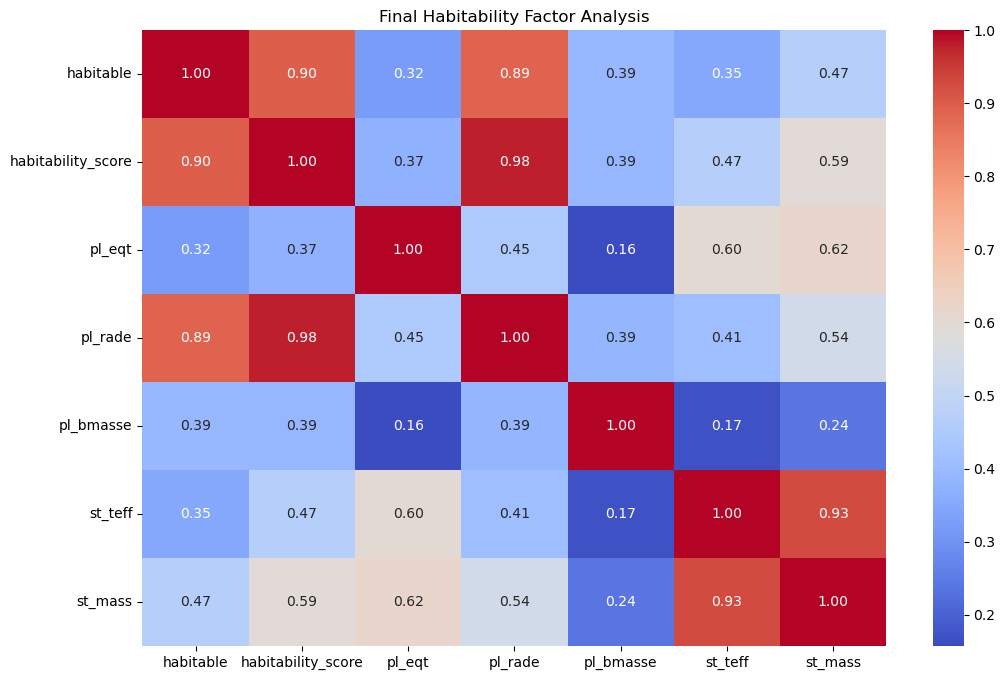

Final DataFrame Shape: (450, 26)


In [21]:
#FEATURE ENGINEERING

df_m1["st_lum"] = (df_m1["st_rad"]**2) * ((df_m1["st_teff"]/5778)**4)

# A. HABITABILITY SCORE INDEX 
# Temperature score (best near Earth ~288K, habitable range wide)
df_m1["temp_score"] = (1 - abs(df_m1["pl_eqt"] - 288) / 120).clip(0, 1)

# Radius score (Earth ≈ 1 Earth radius)
df_m1["radius_score"] = (1 - abs(df_m1["pl_rade"] - 1) / 2).clip(0, 1)

# Distance score (Earth ≈ 1 AU)
df_m1["dist_score"] = (1 - abs(df_m1["pl_orbsmax"] - 1) / 1.5).clip(0, 1)

# Stellar luminosity score (Earth-like stars best near 1)
df_m1["lum_score"] = (1 - abs(df_m1["st_lum"] - 1) / 2).clip(0, 1)

# FINAL HABITABILITY SCORE (weighted)
df_m1["habitability_score"] = (
    0.4 * df_m1["temp_score"] +
    0.2 * df_m1["radius_score"] +
    0.2 * df_m1["dist_score"] +
    0.2 * df_m1["lum_score"]
)

# Binary target
df_m1["habitable"] = (df_m1["habitability_score"] > 0.55).astype(int)

print(df_m1["habitable"].value_counts())

# B. STELLAR COMPATIBILITY INDEX 
df_m1["stellar_temp_score"] = 1 - abs(df_m1["st_teff"] - 5778) / df_m1["st_teff"].max()
df_m1["stellar_mass_score"] = 1 - abs(df_m1["st_mass"] - 1) / df_m1["st_mass"].max()
df_m1["stellar_compatibility_index"] = (df_m1["stellar_temp_score"].clip(0,1) + df_m1["stellar_mass_score"].clip(0,1)) / 2

# C. ORBITAL STABILITY FACTOR 
# Using Orbital period and Semi-major axis 
df_m1["orbital_stability"] = (1 - abs(df_m1["pl_orbsmax"] - 1)).clip(0, 1) * (1 - abs(df_m1["pl_orbper"] - 365) / 365).clip(0, 1)


# D. TARGET VARIABLE CREATION (Binary Class)
df_m1['habitable'] = (df_m1['habitability_score'] > 0.3).astype(int)

# FEATURE SCALING 
scaler = MinMaxScaler()
scale_features = ['pl_eqt', 'pl_rade', 'pl_bmasse', 'st_teff', 'habitability_score']
df_m1[scale_features] = scaler.fit_transform(df_m1[scale_features])

# VISUALIZATION (HEATMAP) 
plt.figure(figsize=(12, 8))
heatmap_cols = ['habitable', 'habitability_score', 'pl_eqt', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_mass']
sns.heatmap(df_m1[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Final Habitability Factor Analysis")
plt.show()
print(f"Final DataFrame Shape: {df_m1.shape}")




In [22]:
print(df_m1.columns)

Index(['pl_name', 'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt',
       'st_teff', 'st_rad', 'st_mass', 'st_met', 'spec_F', 'spec_G', 'spec_K',
       'spec_M', 'spec_m', 'st_lum', 'temp_score', 'radius_score',
       'dist_score', 'lum_score', 'habitability_score', 'habitable',
       'stellar_temp_score', 'stellar_mass_score',
       'stellar_compatibility_index', 'orbital_stability'],
      dtype='object')


In [24]:
print(df_m1["habitable"].value_counts())

habitable
0    251
1    199
Name: count, dtype: int64


In [ ]:
save_dir = '../data/processed'
os.makedirs(save_dir, exist_ok=True) 

# 2. File Save karein
save_path = os.path.join(save_dir, 'preprocessed.csv')
df_m1.to_csv(save_path, index=False)

ExoHabitAI ML Model Trainngi

In [2]:
import pandas as pd
import numpy as np
# ML Libraries import 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report


In [3]:
# load file 
df_ml = pd.read_csv('../data/processed/preprocessed.csv')

In [4]:
# 2. X (Features) aur y (Target) select karein
X = df_ml.drop(columns=['habitable','pl_name','habitability_score','radius_score'], errors='ignore')
X = X.select_dtypes(include=[np.number,'bool']).astype(float)
y = df_ml['habitable']

In [6]:
# 3. Train-Test Split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
X = X.astype(float)

print("Train label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())

Train: (360, 22), Test: (90, 22)
Train label counts:
 habitable
0    201
1    159
Name: count, dtype: int64

Test label counts:
 habitable
0    50
1    40
Name: count, dtype: int64


In [ ]:
X_train.info()

In [8]:
# BASELINE MODELS

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
dt = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))

print(" Decision Tree ")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Recall:", recall_score(y_test, pred_dt))


Logistic Regression
Accuracy: 0.9777777777777777
Recall: 0.95
 Decision Tree 
Accuracy: 0.9666666666666667
Recall: 0.975


In [9]:
 # ==============================
# PRIMARY MODELS (ADVANCED)
# ==============================

from sklearn.ensemble import RandomForestClassifier

# model create karo
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

# train karo
rf.fit(X_train, y_train)

# predict karo
pred_rf = rf.predict(X_test)

# result print karo
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))

#3. Provides feature importance

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop Important Features:")
print(importance.head(10))


Random Forest
Accuracy: 0.9888888888888889
Recall: 0.975

Top Important Features:
pl_rade               0.397767
pl_bmasse             0.274062
st_rad                0.048454
st_met                0.045157
st_lum                0.044771
st_mass               0.038907
pl_eqt                0.022400
stellar_temp_score    0.019579
st_teff               0.019166
orbital_stability     0.018376
dtype: float64


In [10]:
# XGBOOST MODEL
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("\nXGBoost")
print("Accuracy:", accuracy_score(y_test, pred_xgb))
print("Recall:", recall_score(y_test, pred_xgb))


XGBoost
Accuracy: 0.9777777777777777
Recall: 0.975


In [11]:
# SVM MODEL (OPTIONAL)
from sklearn.svm import SVC

svm = SVC(kernel="rbf", class_weight="balanced")

svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))


SVM
Accuracy: 0.5555555555555556
Recall: 0.0


In [12]:
# STEP 5: Feature Scaling & Pipelines 

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, classification_report

# ==============================
# Logistic Regression Pipeline
# ==============================

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipe_lr.fit(X_train, y_train)
pred_lr_pipe = pipe_lr.predict(X_test)

print("\nPipeline Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr_pipe))
print("Recall:", recall_score(y_test, pred_lr_pipe))
print(classification_report(y_test, pred_lr_pipe))


# ==============================
# SVM Pipeline
# ==============================

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", class_weight="balanced"))
])

pipe_svm.fit(X_train, y_train)
pred_svm_pipe = pipe_svm.predict(X_test)

print("\nPipeline SVM")
print("Accuracy:", accuracy_score(y_test, pred_svm_pipe))
print("Recall:", recall_score(y_test, pred_svm_pipe))
print(classification_report(y_test, pred_svm_pipe))


Pipeline Logistic Regression
Accuracy: 0.9888888888888889
Recall: 0.975
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        40

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90


Pipeline SVM
Accuracy: 0.9777777777777777
Recall: 0.975
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.97      0.97      0.97        40

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90



In [13]:
#Step 6 Model Training

import joblib, os
os.makedirs("models", exist_ok=True)

# Random Forest train + save
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
joblib.dump(rf, "models/random_forest.pkl")

# XGBoost train + save
from xgboost import XGBClassifier
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train)
joblib.dump(xgb, "models/xgboost.pkl")

print("Models trained & saved!")

Models trained & saved!


Accuracy : 0.9888888888888889
Precision: 1.0
Recall   : 0.975
F1-score : 0.9873417721518988
ROC-AUC  : 0.9994999999999999

Confusion Matrix:

[[50  0]
 [ 1 39]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        40

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



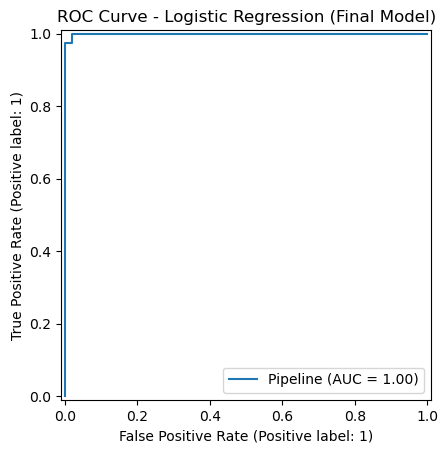

In [14]:
# ==============================
# Step 7: Model Evaluation (FINAL)
# ==============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Final Selected Model
model = pipe_lr

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ==============================
# Evaluation Metrics
# ==============================

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

# ==============================
# Confusion Matrix
# ==============================

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ==============================
# Classification Report
# ==============================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# ROC Curve
# ==============================

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression (Final Model)")
plt.show()

In [15]:
#Step 8: Hyperparameter Tuning
#RANDOM FOREST TUNING (GridSearchCV)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10]
}

grid_rf = GridSearchCV(rf, rf_grid, cv=3, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)
print("Tuned RF Test Recall:", recall_score(y_test, best_rf.predict(X_test)))

Best RF Params: {'max_depth': None, 'n_estimators': 100}
Tuned RF Test Recall: 0.975


In [16]:
#XGBOOST TUNING

from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="logloss", random_state=42)

xgb_grid = {
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "n_estimators": [200, 300],
}

grid_xgb = GridSearchCV(xgb, xgb_grid, cv=3, scoring="recall", n_jobs=-1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print("Best XGB Params:", grid_xgb.best_params_)
print("Tuned XGB Test Recall:", recall_score(y_test, best_xgb.predict(X_test)))

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Tuned XGB Test Recall: 0.975


In [17]:
# ==============================
# STEP 9: Model Comparison & Final Selection
# ==============================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------
# Models to Compare
# ------------------------------

models = {

    "Baseline Logistic Regression": lr,
    "Baseline Decision Tree": dt,
    "Logistic Regression (Pipeline)": pipe_lr,
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb
}


results = []

# ------------------------------
# Evaluate Each Model
# ------------------------------

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# ------------------------------
# Comparison Table
# ------------------------------

comparison_df = pd.DataFrame(results)

print("\nModel Comparison Table:\n")
print(comparison_df)

# ------------------------------
# Final Model Selection
# ------------------------------

comparison_df = comparison_df.sort_values(
    by=["F1-score", "Recall"],
    ascending=False
)

best_name = comparison_df.iloc[0]["Model"]

print("\nBest Model Selected:", best_name)


Model Comparison Table:

                            Model  Accuracy  Precision  Recall  F1-score
0    Baseline Logistic Regression  0.977778    1.00000   0.950  0.974359
1          Baseline Decision Tree  0.966667    0.95122   0.975  0.962963
2  Logistic Regression (Pipeline)  0.988889    1.00000   0.975  0.987342
3             Tuned Random Forest  0.988889    1.00000   0.975  0.987342
4                   Tuned XGBoost  0.977778    0.97500   0.975  0.975000

Best Model Selected: Logistic Regression (Pipeline)


In [18]:
# STEP 10: Habitability Scoring & Ranking

import os
os.makedirs("data/processed", exist_ok=True)

# Final model
model = pipe_lr

# Get probabilities (class 1 = habitable)
scores = model.predict_proba(X_test)[:, 1]

# Create ranking dataframe
rank_df = X_test.copy()
rank_df["Habitability_Score"] = scores

# Sort & rank
rank_df = rank_df.sort_values(by="Habitability_Score", ascending=False)
rank_df["Rank"] = range(1, len(rank_df) + 1)

# Save file
rank_df.to_csv("data/processed/habitability_ranked.csv", index=False)

print("Habitability ranking file saved!")


Habitability ranking file saved!


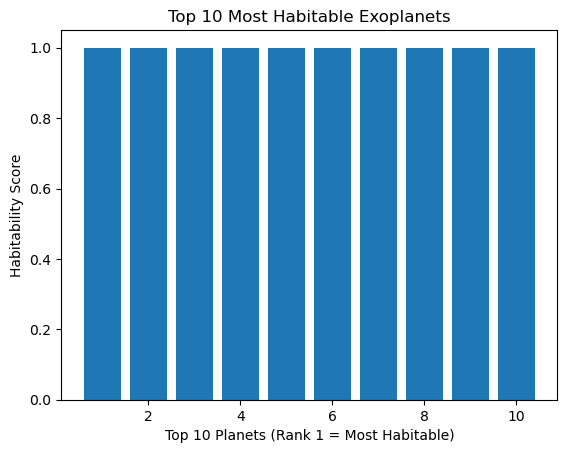

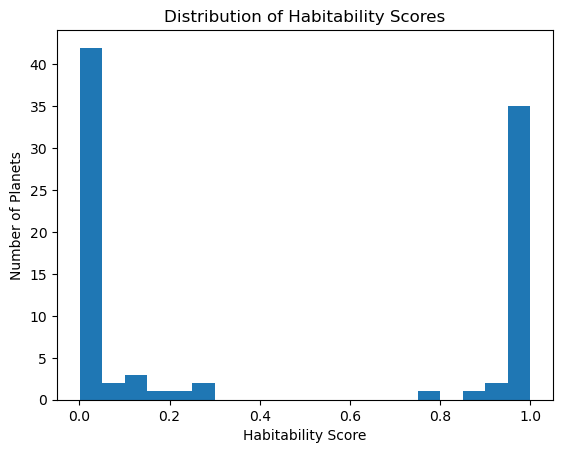

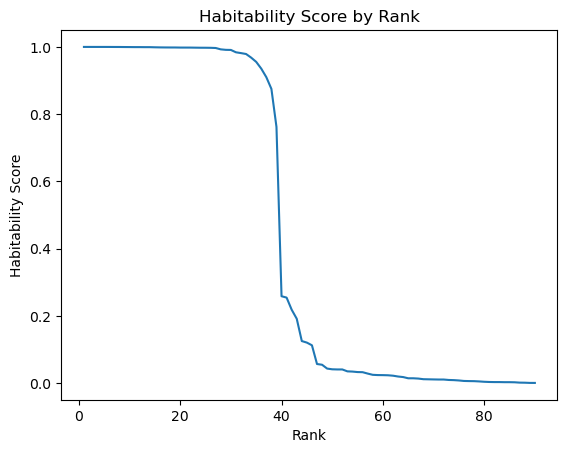

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/habitability_ranked.csv")

top10 = df.head(10)

plt.figure()
plt.bar(range(1, 11), top10["Habitability_Score"])
plt.xlabel("Top 10 Planets (Rank 1 = Most Habitable)")
plt.ylabel("Habitability Score")
plt.title("Top 10 Most Habitable Exoplanets")
plt.show()




plt.figure()
plt.hist(df["Habitability_Score"], bins=20)
plt.xlabel("Habitability Score")
plt.ylabel("Number of Planets")
plt.title("Distribution of Habitability Scores")
plt.show()




plt.figure()
plt.plot(df["Rank"], df["Habitability_Score"])
plt.xlabel("Rank")
plt.ylabel("Habitability Score")
plt.title("Habitability Score by Rank")
plt.show()


Top Contributing Features:

               Feature  Coefficient  Importance
0              pl_rade     4.943295    4.943295
21   orbital_stability     0.548304    0.548304
1            pl_bmasse     0.521442    0.521442
8               st_met     0.512593    0.512593
4               pl_eqt    -0.437577    0.437577
14              st_lum     0.373685    0.373685
5              st_teff     0.242593    0.242593
18  stellar_temp_score     0.242593    0.242593
10              spec_G     0.195806    0.195806
2            pl_orbper    -0.131333    0.131333


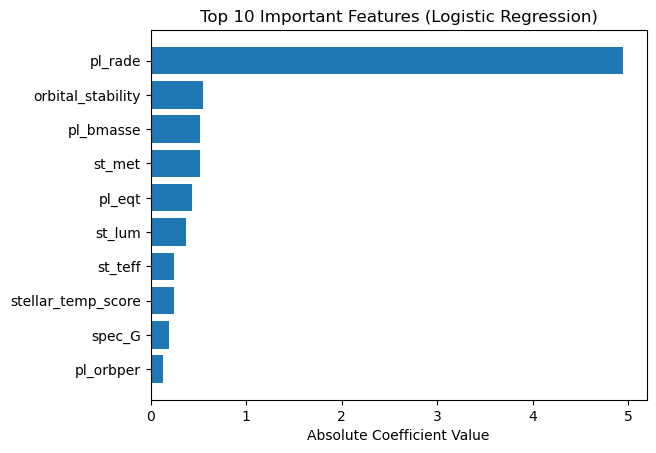

In [21]:
# ==============================
# STEP 11: Model Interpretability
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract trained logistic model from pipeline
log_model = pipe_lr.named_steps["model"]

# Get feature names
feature_names = X_train.columns

# Get coefficients
coefficients = log_model.coef_[0]

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("\nTop Contributing Features:\n")
print(importance_df.head(10))

# ------------------------------
# Plot Top 10 Features
# ------------------------------

top10 = importance_df.head(10)

plt.figure()
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Absolute Coefficient Value")
plt.title("Top 10 Important Features (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# ==============================
# Save Final Selected Model
# ==============================

import os
import joblib

os.makedirs("models", exist_ok=True)

# Save Logistic Regression Pipeline
joblib.dump(pipe_lr, "models/logistic_pipeline.pkl")

print("Model saved successfully in models/")